| Bracket s | Startmodellen n0 | Ronde 1 | Ronde 2 | Ronde 3 | Ronde 4 | Ronde 5 | Ronde 6 | Ronde 7 | Ronde 8 | Ronde 9 | Ronde 10 | Ronde 11 |
| --------- | ---------------- | ------- | ------- | ------- | ------- | ------- | ------- | ------- | ------- | ------- | -------- | -------- |
| 10        | 1024             | 1024    | 512     | 256     | 128     | 64      | 32      | 16      | 8       | 4       | 2        | 1        |
| 9         | 512              | 512     | 256     | 128     | 64      | 32      | 16      | 8       | 4       | 2       | 1        | -        |
| 8         | 256              | 256     | 128     | 64      | 32      | 16      | 8       | 4       | 2       | 1       | -        | -        |
| 7         | 128              | 128     | 64      | 32      | 16      | 8       | 4       | 2       | 1       | -       | -        | -        |
| 6         | 64               | 64      | 32      | 16      | 8       | 4       | 2       | 1       | -       | -       | -        | -        |
| 5         | 32               | 32      | 16      | 8       | 4       | 2       | 1       | -       | -       | -       | -        | -        |
| 4         | 16               | 16      | 8       | 4       | 2       | 1       | -       | -       | -       | -       | -        | -        |
| 3         | 8                | 8       | 4       | 2       | 1       | -       | -       | -       | -       | -       | -        | -        |
| 2         | 4                | 4       | 2       | 1       | -       | -       | -       | -       | -       | -       | -        | -        |
| 1         | 2                | 2       | 1       | -       | -       | -       | -       | -       | -       | -       | -        | -        |
| 0         | 1                | 1       | -       | -       | -       | -       | -       | -       | -       | -       | -        | -        |


Samengevat voor max_epochs = 1024, factor = 2:
| Bracket s | Start-epochs r0 | Ronden in bracket |
| --------- | --------------- | ----------------- |
| 10        | 1               | 11                |
| 9         | 2               | 10                |
| 8         | 4               | 9                 |
| 7         | 8               | 8                 |
| 6         | 16              | 7                 |
| 5         | 32              | 6                 |
| 4         | 64              | 5                 |
| 3         | 128             | 4                 |
| 2         | 256             | 3                 |
| 1         | 512             | 2                 |
| 0         | 1024            | 1                 |


https://chatgpt.com/c/69ce0c9e-32e4-8325-854f-4dd731364874

uitleg hoe het het berekent:
https://chatgpt.com/c/69ce36da-02f8-832a-9bee-529d5aeb46cd

nooit op RMSE trainen -> dit is voor interpretatie

eventuele, verbeterpunten:
- kijken welke batch size het beste is
- Activatiefunctie is nu globaal → je kan ook per laag variëren:
- Dropout (tegen overfitting)
- BatchNormalization

lijst van parameters die aangepast worden met optimization:
- aantal dense lagen: `'num_layers', 3, 10`
- aantal units: `'units_{i}', min_value=32, max_value=512, step=32`
- activation function: `'activation', ['relu', 'tanh', 'softplus']`
- learning rate: `'learning_rate', [1e-5, 1e-4, 1e-3, 1e-2]`

lijst van gekozen parameters:
- a
- a
- a
- a
- a
- a
- a

# GOED

In [32]:
from tensorflow import keras
from kerastuner.tuners import BayesianOptimization
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# GOED

In [19]:
file_path = './datasets/winequality-white.csv'
df = pd.read_csv(file_path, delimiter=";")  

lengte_df = len(df)
temp_split = round(lengte_df * 0.8) # train is 70% van de dataset en validatie is 10% van de dataset. de rest is test_data
train_split = round(temp_split * 0.875)

temp = df[:temp_split]
train = temp[:train_split]
test = temp[train_split:]
val = df[temp_split:]

y_train = train.iloc[:, -1:]
X_train = train.iloc[:, :-1]

y_test = test.iloc[:, -1:]
X_test = test.iloc[:, :-1]

y_val = val.iloc[:, -1:]
X_val = val.iloc[:, :-1]

norm_layer = keras.layers.Normalization()
norm_layer.adapt(X_train)

print(len(df))
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

4898
(3428, 11)
(3428, 1)
(980, 11)
(980, 1)
(490, 11)
(490, 1)


In [33]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()

X = data.data
y = data.target

# train+val en test (90%/10%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# train en val (70%/20% van 90%) ongveer 20%, niet exact
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.22, random_state=42)

norm_layer = keras.layers.Normalization()
norm_layer.adapt(X_train)

# eventueel parameters aanpassen

In [34]:
# --- 2. Modelbuilder functie ---
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=X_train.shape[1:]))
    model.add(norm_layer)
    for i in range(hp.Int('num_layers', 2, 6)):
        model.add(
            keras.layers.Dense(
                units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32),
                activation=hp.Choice('activation', ['relu', 'tanh', 'softplus'])
            )
        )
    
    model.add(keras.layers.Dense(1))  # outputlaag voor regressie

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-5, 1e-4, 1e-3, 1e-2])
        ),
        loss='mse', # wat hij gaat proberen verminderen
        metrics=['mse', 'RootMeanSquaredError'] # dit is puur voor visueel zodat je kan interpreteren hoe het model presteert
    )
    
    return model

# max trials? objective? num_initial_points?

In [35]:
# --- 3. Bayesian Optimization Tuner ---
tuner = BayesianOptimization(
    build_model,
    objective='val_mse', # wat hij naar beneden wilt krijgen
    max_trials=60,  # max aantal hyperparametercombinaties om te proberen
    num_initial_points=20, # hoeveel random hyperparametercombinaties uitproberen voordat hij bayesion optimization toepast?
    directory='../Bachelorproef_modellen/MLP_bay',
    project_name='MLP_bayian_opt'
)

# eventueel patience, batch_size

In [36]:
# --- 4. Start hyperparameter tuning ---
early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # validatie MSE
    patience=5,
    min_delta=0.001,         # kleine verbetering in MAE is al goed
    restore_best_weights=True,
    mode='min'               # MAE moet omlaag
)

tuner.search(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=32, # batch_size=hp.Choice('batch_size', [16, 32, 64]) ?
    callbacks=[early_stopping_cb],
    verbose=1
)

Trial 60 Complete [00h 00m 33s]
val_mse: 0.3017179071903229

Best val_mse So Far: 0.2586812973022461
Total elapsed time: 00h 52m 32s


# GOED

In [37]:
# --- 5. Beste hyperparameters en model ---
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Beste hyperparameters:")
print(best_hp.values)

best_model = tuner.get_best_models(1)[0]

Beste hyperparameters:
{'num_layers': 6, 'units_0': 352, 'activation': 'relu', 'units_1': 512, 'learning_rate': 0.001, 'units_2': 96, 'units_3': 32, 'units_4': 32, 'units_5': 32}


In [38]:
best_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_2 (Normaliza  (None, 8)                 17        
 tion)                                                           
                                                                 
 dense (Dense)               (None, 352)               3168      
                                                                 
 dense_1 (Dense)             (None, 512)               180736    
                                                                 
 dense_2 (Dense)             (None, 96)                49248     
                                                                 
 dense_3 (Dense)             (None, 32)                3104      
                                                                 
 dense_4 (Dense)             (None, 32)                1056      
                                                        

In [39]:
results = best_model.evaluate(X_test, y_test)
print(f"general loss: {results[0]}")
print(f"general mse: {results[1]}")
print(f"general rmse: {results[2]}")

65/65 [==============================] - 0s 2ms/step - loss: 0.2699 - mse: 0.2699 - root_mean_squared_error: 0.5195
general loss: 0.26985761523246765
general mse: 0.26985761523246765
general rmse: 0.5194782018661499


128/128 [==============================] - 0s 2ms/step
Training:  16.598849%
Validatie:  18.32%
MAE: 0.34
RMSE: 0.52
MAPE: 18.78%
R²: 0.80


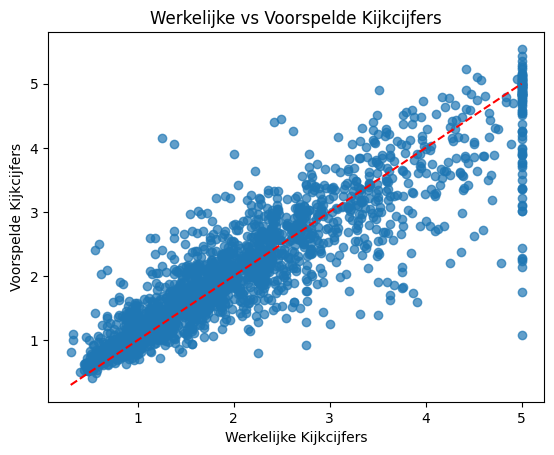

In [40]:
best_model = tuner.get_best_models(1)[0]
# pipeline = onehote encoding, standardizing, decisiontree training ---> trainingsdata
predictions = best_model.predict(X_test)
# pipeline = onehote encoding, standardizing, decisiontree voorspel ---> input

# testen op under en overfitting
train_predictions = best_model.predict(X_train)
val_predictions = best_model.predict(X_val)
print(f"Training:  {mean_absolute_percentage_error(y_train, train_predictions):2%}")
print(f"Validatie:  {mean_absolute_percentage_error(y_val, val_predictions):.2%}")


# Evaluatie
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"R²: {r2:.2f}")

# Visualiseer en interpreteer je resultaten.
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Werkelijke Kijkcijfers')
plt.ylabel('Voorspelde Kijkcijfers')
plt.title('Werkelijke vs Voorspelde Kijkcijfers')
plt.show()

# EXPERIMENTEN

In [41]:
X_new = X_test[:3]  # pretend these are new instances
y_proba = best_model.predict(X_new)

1/1 [==============================] - 0s 16ms/step
